<a href="https://colab.research.google.com/github/Rakesh-0479/Rakesh-T/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from textblob import TextBlob

In [2]:
df = pd.read_csv("suzlon_data.csv")

In [3]:
print(df.columns)

Index(['Title', 'Description'], dtype='object')


In [4]:
df['combined_text'] = df['Title'].astype(str) + " " + df['Description'].astype(str)

In [5]:
def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

In [6]:
df['sentiment_score'] = df['combined_text'].apply(get_sentiment)

In [7]:
def label_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

In [8]:
df['sentiment_label'] = df['sentiment_score'].apply(label_sentiment)

In [9]:
print(df[['Title', 'Description', 'sentiment_score', 'sentiment_label']].head())

                                               Title  \
0  "Cennergi selects Suzlon turbines for 138 MW p...   
1    "Suzlon Group wins 16 MW order with Renerco UK"   
2  "We can eradicate energy poverty in India by 2...   
3  "Suzlons 138 MW project for Cennergi amongst p...   
4  "Suzlon Group FY12 Guidance achieved robust US...   

                                         Description  sentiment_score  \
0  "Cennergi is a joint venture by Exxaro and Tat...         0.152038   
1  "Pune Edinburgh Suzlon Group-subsidiary REpowe...         0.084412   
2  "New Delhi Pune Suzlon Group Chairman Tulsi Ta...         0.223858   
3  "Supply and EPC contract for 66 S97 Suzlon tur...         0.125135   
4  "Revenues of Rs 21082 cr US 375 bn a YoY growt...         0.128043   

  sentiment_label  
0        Positive  
1         Neutral  
2        Positive  
3        Positive  
4        Positive  


In [10]:
df.to_csv("combined_sentiment_analysis.csv", index=False)
print("✅ Sentiment analysis saved to 'combined_sentiment_analysis.csv'")

✅ Sentiment analysis saved to 'combined_sentiment_analysis.csv'


In [13]:
sentiment_counts = df['sentiment_label'].value_counts()

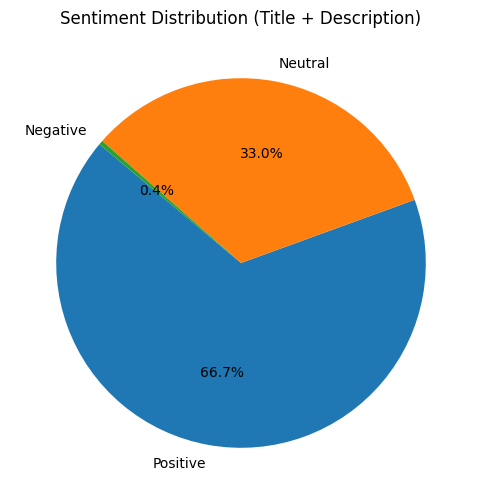

In [14]:
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Sentiment Distribution (Title + Description)")
plt.show()